In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
sim = AerSimulator()
print('Qiskit ready ✓')

Qiskit ready ✓


In [2]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.3 MB/s eta 0:00:00


In [ ]:
qc = QuantumCircuit(1)
qc.x(0)    # Pauli-X: flip |0⟩ → |1⟩
qc.h(0)    # Hadamard: create superposition
qc.s(0)    # S gate: phase shift π/2
qc.t(0)    # T gate: phase shift π/4
qc.rz(np.pi/3, 0)  # Rz rotation by π/3
print(qc.draw(output='text'))

   ┌───┐┌───┐┌───┐┌───┐┌─────────┐
q: ┤ X ├┤ H ├┤ S ├┤ T ├┤ Rz(π/3) ├
   └───┘└───┘└───┘└───┘└─────────┘


In [ ]:
qc_cnot = QuantumCircuit(2, 2)
qc_cnot.x(0)     # Set control qubit to |1⟩
qc_cnot.cx(0, 1) # CNOT: control=0, target=1
qc_cnot.measure([0,1],[0,1])
print(qc_cnot.draw(output='text'))

job = sim.run(qc_cnot, shots=1024)
print(f'Result: {job.result().get_counts()}')

     ┌───┐     ┌─┐   
q_0: ┤ X ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
Result: {'11': 1024}


In [4]:
def bell_circuit(state='phi_plus'):
    """Create one of the four Bell states."""
    qc = QuantumCircuit(2, 2)
    if state in ('psi_plus', 'psi_minus'):
        qc.x(0)            # Flip first qubit for Ψ states
    qc.h(0)                # Hadamard on control
    qc.cx(0, 1)            # CNOT
    if state in ('phi_minus', 'psi_minus'):
        qc.z(0)            # Z phase for minus states
    qc.measure([0,1],[0,1])
    return qc

# Prepare Φ⁺ = (|00⟩ + |11⟩)/√2
qc_bell = bell_circuit('phi_plus')
print('Bell state Φ⁺ circuit:')
print(qc_bell.draw(output='text'))

job = sim.run(qc_bell, shots=2048)
counts = job.result().get_counts()
plot_histogram(counts, title='Bell State Φ⁺ Measurements')
plt.show()

Bell state Φ⁺ circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


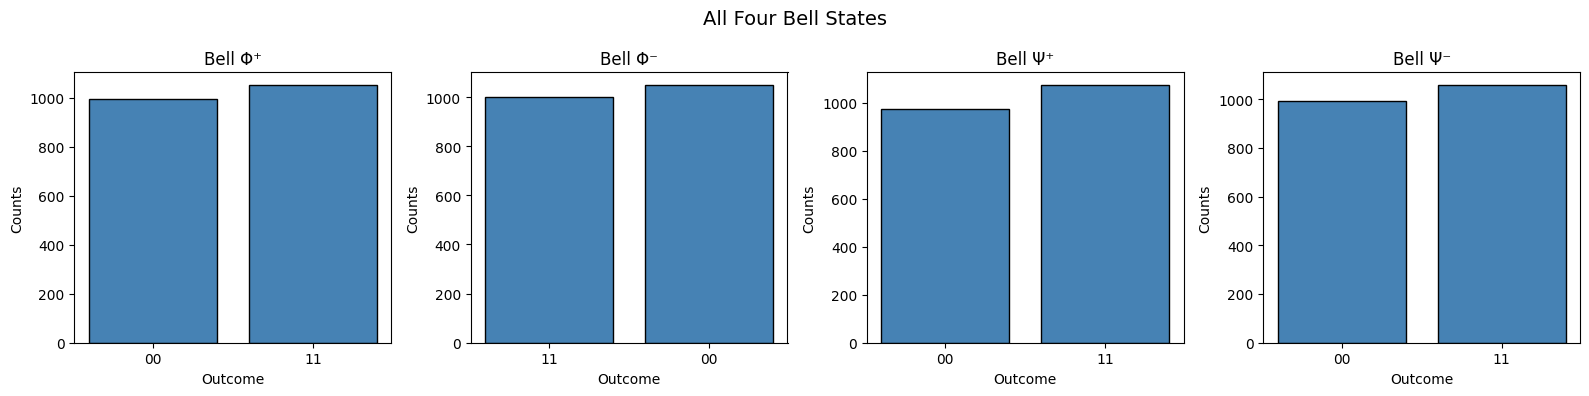

In [5]:
bell_states = ['phi_plus', 'phi_minus', 'psi_plus', 'psi_minus']
labels = ['Φ⁺','Φ⁻','Ψ⁺','Ψ⁻']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, state, label in zip(axes, bell_states, labels):
    qc = bell_circuit(state)
    counts = sim.run(qc, shots=2048).result().get_counts()
    ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
    ax.set_title(f'Bell {label}')
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Counts')

plt.suptitle('All Four Bell States', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
qc_ghz = QuantumCircuit(3, 3)

qc_ghz.h(0)        # put qubit 0 into superposition: (|0⟩ + |1⟩)/√2
qc_ghz.cx(0, 1)     # CNOT: qubit 0 is control, qubit 1 is target → copies qubit 0's value onto qubit 1
qc_ghz.cx(0, 2)     # CNOT: qubit 0 is control, qubit 2 is target → copies qubit 0's value onto qubit 2

qc_ghz.measure([0,1,2], [0,1,2])
print(qc_ghz.draw(output='text'))

     ┌───┐             ┌─┐   
q_0: ┤ H ├──■────■─────┤M├───
     └───┘┌─┴─┐  │  ┌─┐└╥┘   
q_1: ─────┤ X ├──┼──┤M├─╫────
          └───┘┌─┴─┐└╥┘ ║ ┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     1  0  2 


In [7]:
qc_ex2 = QuantumCircuit(2)
qc_ex2.h(0)
qc_ex2.cx(0, 1)
qc_ex2.x(1)
sv = Statevector.from_instruction(qc_ex2)
print(sv)

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


 Key Takeaways
Circuits read left to right; gates apply to qubits in sequence
CNOT is the essential 2-qubit entangling gate
Bell states are maximally entangled — measuring one qubit instantly determines the other
Any quantum computation can be decomposed into single-qubit + CNOT gates

📝 TODO Checklist
Complete GHZ state (Exercise 1)
Analyze statevector (Exercise 2)

Verify Bell state entanglement via statevector entropy

Code is below.

Draw circuits for all 4 Bell states and label them

Code is below.


In [11]:

qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)


sv = Statevector.from_instruction(qc_bell)
print("Full statevector:"
print(sv)

reduced_dm = partial_trace(sv, [1])
print("\nReduced density matrix (qubit 0 only):")
print(reduced_dm)

S = entropy(reduced_dm, base=2)
print(f"\nEntropy: {S}")

Full statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Reduced density matrix (qubit 0 only):
DensityMatrix([[0.5+0.j, 0. +0.j],
               [0. +0.j, 0.5+0.j]],
              dims=(2,))

Entropy: 1.0


In [13]:
qc_phi_plus = QuantumCircuit(2)
qc_phi_plus.h(0)
qc_phi_plus.cx(0,1)
print("Phi+ : (|00> + |11>)/sqrt(2)")
print(qc_phi_plus.draw(output='text'))
print(Statevector.from_instruction(qc_phi_plus))
print()

qc_phi_minus = QuantumCircuit(2)
qc_phi_minus.x(0)
qc_phi_minus.h(0)
qc_phi_minus.cx(0,1)
print("Phi- : (|00> - |11>)/sqrt(2)")
print(qc_phi_minus.draw(output='text'))
print(Statevector.from_instruction(qc_phi_minus))
print()

qc_psi_plus = QuantumCircuit(2)
qc_psi_plus.x(1)
qc_psi_plus.h(0)
qc_psi_plus.cx(0,1)
print ("Psi+ :|01> + |10>)/sqrt(2) ")
print(qc_psi_plus.draw(output='text'))
print(Statevector.from_instruction(qc_psi_plus))
print()


qc_psi_minus = QuantumCircuit(2)
qc_psi_minus.x(0)
qc_psi_minus.x(1)
qc_psi_minus.h(0)
qc_psi_minus.cx(0,1)
print ("Psi- :|01> - |10>)/sqrt(2) ")
print(qc_psi_minus.draw(output='text'))
print(Statevector.from_instruction(qc_psi_minus))
print()




Phi+ : (|00> + |11>)/sqrt(2)
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Phi- : (|00> - |11>)/sqrt(2)
     ┌───┐┌───┐     
q_0: ┤ X ├┤ H ├──■──
     └───┘└───┘┌─┴─┐
q_1: ──────────┤ X ├
               └───┘
Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))

Psi+ :|01> + |10>)/sqrt(2) 
     ┌───┐     
q_0: ┤ H ├──■──
     ├───┤┌─┴─┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘
Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))

Psi- :|01> - |10>)/sqrt(2) 
     ┌───┐┌───┐     
q_0: ┤ X ├┤ H ├──■──
     ├───┤└───┘┌─┴─┐
q_1: ┤ X ├─────┤ X ├
     └───┘     └───┘
Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))

